In [63]:

import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from google.colab import drive

In [64]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
IMAGE_SIZE = 224

BATCH_SIZE = 185
CHANNELS = 3
EPOCH = 50

In [66]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/SkinClassification/dataset/DATA/train",
    shuffle= True,
    image_size= (IMAGE_SIZE, IMAGE_SIZE),
    batch_size= BATCH_SIZE

)

Found 440 files belonging to 5 classes.


In [67]:
class_names= dataset.class_names
class_names

['Acne', 'Actinic Keratosis', 'Basal Cell Carcinoma', 'Eczemaa', 'Rosacea']

In [68]:
len(dataset)

3

In [69]:
#plt.figure(figsize=(10,8))
#for image_batch, label_batch in dataset.take(1):
#  for i in range (12):
#    ax= plt.subplot(3,4,i+1)
#    plt.imshow( image_batch[i].numpy().astype("uint8"))
#    plt.title(class_names[label_batch[i]])
#    plt.axis("off")

Dari dataset yang ada, dataset akan dibagi menjadi 2 bagian yaitu: Training Dataset dan Validating Dataset. untuk data training diambil 80% dari dataset yang ada, dan untuk data validasi diambil 20% dari dataset.

In [70]:
def get_dataset(ds, train_split = 0.8, val_split= 0.2, shuffle= True, shuffle_size= 10000):

  ds_size = len(ds)

  if shuffle:
    ds= ds.shuffle(shuffle_size, seed=12)

  train_size = int(ds_size*train_split)
  val_size = int(ds_size*val_split)

  train_ds= ds.take(train_size)
  val_ds= ds.skip(train_size)


  return train_ds, val_ds

In [71]:
train_ds, val_ds= get_dataset(dataset)

In [72]:
len(train_ds)

2

In [73]:
len(val_ds)

1

In [74]:
train_ds= train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds= val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [75]:
resize_and_rescale= tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0/255)

])

In [76]:
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2)
])

In [77]:
# input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
# n_classes= 5

# model= models.Sequential([
#     # resize_and_rescale,
#     # data_augmentation,
#     #block 1:
#     layers.Conv2D(64,(3,3), activation= 'relu', padding= 'same', input_shape= input_shape),
#     layers.Conv2D(64,(3,3), activation= 'relu', padding= 'same', input_shape= input_shape),
#     layers.MaxPool2D((2,2)),

#     #block 2:
#     layers.Conv2D(128,(3,3), padding= 'same', activation= 'relu'),
#     layers.Conv2D(128,(3,3), padding= 'same', activation= 'relu'),
#     layers.MaxPool2D((2,2)),

#     #block 3:
#     layers.Conv2D(256,(3,3), padding= 'same', activation= 'relu'),
#     layers.Conv2D(256,(3,3), padding= 'same', activation= 'relu'),
#     layers.Conv2D(256,(3,3), padding= 'same', activation= 'relu'),
#     layers.MaxPool2D((2,2)),

#     #block 4:
#     layers.Conv2D(512,(3,3), padding= 'same', activation= 'relu'),
#     layers.Conv2D(512,(3,3), padding= 'same', activation= 'relu'),
#     layers.Conv2D(512,(3,3), padding= 'same', activation= 'relu'),
#     layers.MaxPool2D((2,2)),

#     #block 5:
#     layers.Conv2D(512,(3,3), padding= 'same', activation= 'relu'),
#     layers.Conv2D(512,(3,3), padding= 'same', activation= 'relu'),
#     layers.Conv2D(512,(3,3), padding= 'same', activation= 'relu'),
#     layers.MaxPool2D((2,2)),

#     layers.Flatten(),
#     layers.Dense(4096,activation= 'relu'),
#     layers.Dense(4096,activation= 'relu'),
#     layers.Dense(n_classes, activation= 'softmax')
# ])

# model.build(input_shape = input_shape)

In [78]:
# model.summary()

In [79]:
# model.compile(
#     optimizer= 'adam',
#     loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits= False),
#     metrics=['accuracy']
# )

In [80]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = VGG16(weights='imagenet', include_top=False)
base_model.trainable = False
# x=  resize_and_rescale
# x = data_augmentation
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer= 'adam',
    loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits= False),
    metrics=['accuracy']
)

In [81]:
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 block1_conv1 (Conv2D)       (None, None, None, 64)    1792      
                                                                 
 block1_conv2 (Conv2D)       (None, None, None, 64)    36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, None, None, 64)    0         
                                                                 
 block2_conv1 (Conv2D)       (None, None, None, 128)   73856     
                                                                 
 block2_conv2 (Conv2D)       (None, None, None, 128)   147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, None, None, 128)   0   

In [82]:
history= model.fit(
    train_ds,
    epochs= EPOCH,
    batch_size= BATCH_SIZE,
    verbose=1,
    validation_data= val_ds
)

Epoch 1/50
2/2 [==============================] - 7s 3s/step - loss: 6.8673 - accuracy: 0.2027 - val_loss: 11.7147 - val_accuracy: 0.2714
Epoch 2/50
2/2 [==============================] - 2s 1s/step - loss: 9.2765 - accuracy: 0.3973 - val_loss: 6.7378 - val_accuracy: 0.4143
Epoch 3/50
2/2 [==============================] - 2s 1s/step - loss: 5.4193 - accuracy: 0.4514 - val_loss: 1.7885 - val_accuracy: 0.5714
Epoch 4/50
2/2 [==============================] - 2s 1s/step - loss: 1.4419 - accuracy: 0.6811 - val_loss: 1.4195 - val_accuracy: 0.6714
Epoch 5/50
2/2 [==============================] - 2s 1s/step - loss: 1.7325 - accuracy: 0.6162 - val_loss: 2.7485 - val_accuracy: 0.5000
Epoch 6/50
2/2 [==============================] - 2s 1s/step - loss: 2.2215 - accuracy: 0.6054 - val_loss: 1.3465 - val_accuracy: 0.7714
Epoch 7/50
2/2 [==============================] - 2s 1s/step - loss: 1.0962 - accuracy: 0.7757 - val_loss: 0.8477 - val_accuracy: 0.8000
Epoch 8/50
2/2 [========================

In [83]:
test_ds= tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/SkinClassification/dataset/DATA/testing",
    shuffle= True,
    image_size= (IMAGE_SIZE, IMAGE_SIZE),
    batch_size= BATCH_SIZE

)

Found 185 files belonging to 5 classes.


In [84]:
model.evaluate(test_ds)

1/1 [==============================] - 2s 2s/step - loss: 1.6090 - accuracy: 0.6324


[1.6089632511138916, 0.6324324607849121]

In [85]:
model.save('model_vgg')

In [86]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [87]:
acc= history.history['accuracy']
val_acc= history.history['val_accuracy']

loss= history.history['loss']
val_loss= history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Accuracy')

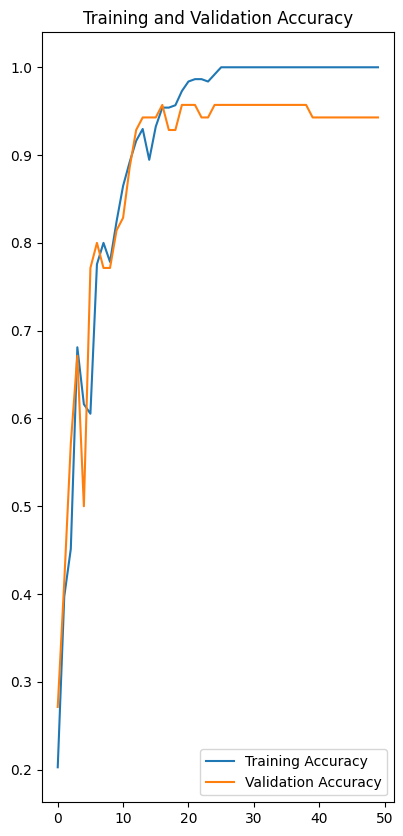

In [88]:
plt.figure(figsize= (10,10))
plt.subplot(1,2,1)
plt.plot(range(EPOCH), acc, label= 'Training Accuracy')
plt.plot(range(EPOCH), val_acc, label= 'Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')



Text(0.5, 1.0, 'Training and Validation loss')

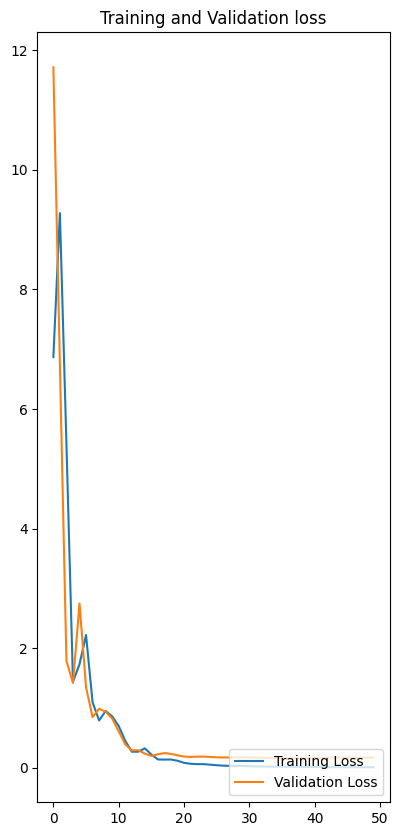

In [89]:
plt.figure(figsize= (10,10))
plt.subplot(1,2,1)
plt.plot(range(EPOCH), loss, label= 'Training Loss')
plt.plot(range(EPOCH), val_loss, label= 'Validation Loss')
plt.legend(loc='lower right')
plt.title('Training and Validation loss')


First image to predict:
Actual Label:  Eczemaa
6/6 [==============================] - 1s 136ms/step
Predicted Label:  Eczemaa


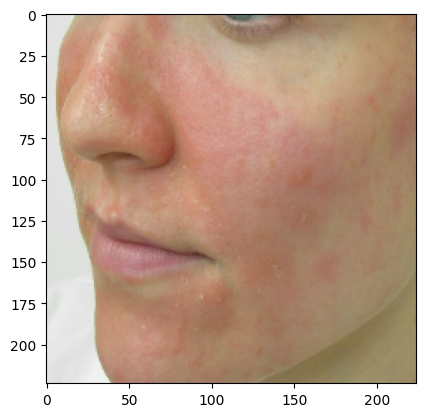

In [90]:
for image_batch, label_batch in test_ds.take(1):
  first_image= image_batch[0].numpy().astype('uint8')
  first_label= label_batch[0].numpy()


  print("First image to predict:")
  plt.imshow(first_image)
  print("Actual Label: ", class_names[first_label])
  batch_prediction= model.predict(image_batch)
  print("Predicted Label: ", class_names[np.argmax(batch_prediction[0])])




In [91]:
def predict(model, img):
  img_array= tf.keras.preprocessing.image.img_to_array(images[i].numpy())
  img_array= tf.expand_dims(img_array, 0)

  predictions= model.predict(img_array)

  predicted_class= class_names[np.argmax(predictions[0])]

  return predicted_class

In [ ]:
history_pred_class= np.array([])
history_actual_class= np.array([])

plt.figure(figsize=(20,120))
for images, labels in test_ds.take(1):
  for i in range(185):
    ax= plt.subplot(37,5, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))

    predicted_class= predict(model, images[i].numpy())
    actual_class= class_names[labels[i]]

    history_pred_class= np.append(history_pred_class, predicted_class)
    history_actual_class= np.append(history_actual_class, actual_class)
    plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class}.")
    plt.axis("off")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

conf_matrix= confusion_matrix(history_actual_class, history_pred_class)
print("Confusion Matrix: ")
print(conf_matrix)

Confusion Matrix: 
[[32  0  3  0  2]
 [ 6 17  9  2  3]
 [ 0  2 28  5  2]
 [ 3  2  5 24  3]
 [ 4  4  2  2 25]]


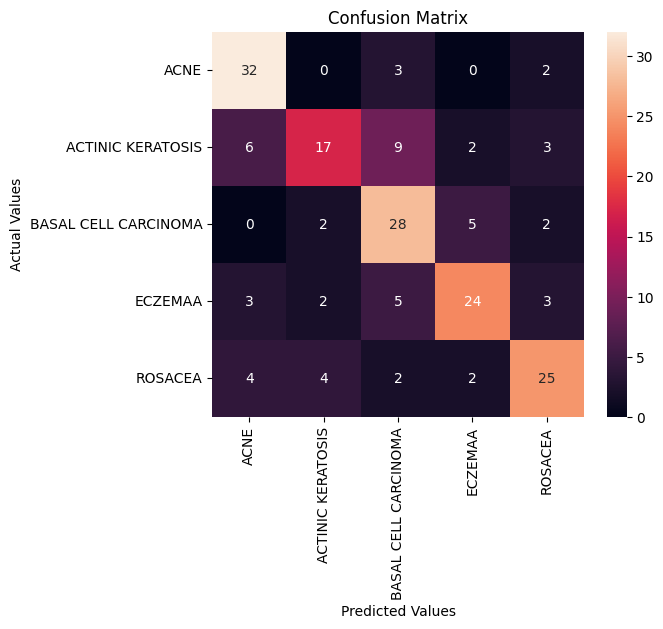

In [ ]:
import pandas as pd
import seaborn as sns

conf_matrix_df = pd.DataFrame(conf_matrix,
                     index = ['ACNE','ACTINIC KERATOSIS','BASAL CELL CARCINOMA','ECZEMAA','ROSACEA'],
                     columns = ['ACNE','ACTINIC KERATOSIS','BASAL CELL CARCINOMA','ECZEMAA','ROSACEA'])

#Plotting the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix_df, annot=True)
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

In [ ]:
# import cv2

# test_img= cv2.imread("/content/drive/MyDrive/SkinClassification/dataset/test_img.jpg")
# resize_and_rescale(test_img)
# data_augmentation(test_img)
# plt.imshow(test_img.astype("uint8"))

# predicted_class= predict(model, test_img)
# plt.title(f"Predicted: {predicted_class}.")
# plt.axis("off")
